In [1]:
# Load library
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['lines.linewidth'] = 0.6


In [2]:
# Load data
data = pd.read_excel('data/1-raw/medication_step_up.xlsx', sheet_name='Data for KM and Cox')
# Drop row without medication step up value 
data.drop(index=62, inplace=True) 

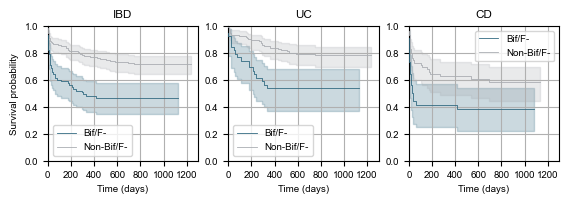

In [3]:

fig = plt.figure(figsize=(6.6, 1.75))
ax = fig.add_subplot(131)

cmap = {0: '#326a81',
        1: '#aaadb2'}
label = {0:'Bif/F-',
         1:'Non-Bif/F-'}
for cl in [0, 1]:
    idx = data.index[data['Microbial enterotypes'] == cl]
    
    durations = data.loc[idx, :]['Medication step up\nduration'].values
    event_observed = data.loc[idx, :]['Medication step up\n1: No\n2: Yes'].values - 1
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed, label=label[cl])

    kmf.plot_survival_function(c=cmap[cl], zorder=10, ax=ax)

ax.grid(zorder=2)
    
ax.set_xlabel("Time (days)")
ax.set_ylabel("Survival probability")
ax.set_title('IBD')    
ax.set_xticks([0, 200, 400, 600, 800, 1000, 1200])
ax.set_xticklabels([0, 200, 400, 600, 800, 1000, 1200])
ax.set_xlim(0, 1300)
ax.set_ylim(0, 1)


ax2 = fig.add_subplot(132)

for cl in [0, 1]:
    idx = data.index[(data['Microbial enterotypes'] == cl) & (data['IBD_type\n\n1. UC\n2. CD'] == 1)]
    
    durations = data.loc[idx, :]['Medication step up\nduration'].values
    event_observed = data.loc[idx, :]['Medication step up\n1: No\n2: Yes'].values - 1
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed, label=label[cl])
    kmf.plot_survival_function(c=cmap[cl], zorder=10, ax=ax2)

ax2.grid(zorder=2)
ax2.set_title('UC')    
ax2.set_xlabel("Time (days)")
ax2.set_xticks([0, 200, 400, 600, 800, 1000, 1200])
ax2.set_xticklabels([0, 200, 400, 600, 800, 1000, 1200])
ax2.set_xlim(0, 1300)
ax2.set_ylim(0, 1)

ax3 = fig.add_subplot(133)

for cl in [0, 1]:
    idx = data.index[(data['Microbial enterotypes'] == cl) & (data['IBD_type\n\n1. UC\n2. CD'] == 2)]
    
    durations = data.loc[idx, :]['Medication step up\nduration'].values
    event_observed = data.loc[idx, :]['Medication step up\n1: No\n2: Yes'].values - 1
    
    kmf = KaplanMeierFitter()
    kmf.fit(durations, event_observed, label=label[cl])

    kmf.plot_survival_function(c=cmap[cl], zorder=10, ax=ax3)

ax3.set_xlabel("Time (days)")

ax3.grid(zorder=2)
ax3.set_title('CD')    
ax3.set_xticks([0, 200, 400, 600, 800, 1000, 1200])
ax3.set_xticklabels([0, 200, 400, 600, 800, 1000, 1200])
ax3.set_xlim(0, 1300)
ax3.set_ylim(0, 1)

fig.savefig('figures/survival_analysis/km_plot.pdf')